# Suffix-Level Attribution Aggregation Analysis

This notebook computes Integrated Gradients attributions for the **full predicted suffix**, aggregated and weighted by prediction probability at each step.

## How it works:

1. **Autoregressive suffix prediction**: Starting from the prefix, predict step 1, feed it back, predict step 2, etc. until EOS or max length.

2. **Attribution at each step**: For each suffix step, compute IG attributions targeting that step's prediction.

3. **Probability weighting**: Weight each step's attributions by the prediction probability (softmax for activities, confidence for time).

4. **Aggregation**: Final attribution = Σ(prob_i × attr_i) / Σ(prob_i)

**Example**: If the model predicts a 3-step suffix with probabilities [0.9, 0.7, 0.8]:
- Step 1 attribution weighted by 0.9
- Step 2 attribution weighted by 0.7  
- Step 3 attribution weighted by 0.8
- Final = (0.9×attr1 + 0.7×attr2 + 0.8×attr3) / (0.9+0.7+0.8)

This gives higher weight to confident predictions.

In [55]:
import importlib
import sys
import torch
import torch.nn.functional as F
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')

from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_decoder_forward_simplified import PSP_Model_simplified
from aa_philipp.model_with_integrated_gradients.targeter import ActivityTargeter, TimeTargeter
from aa_philipp.model_with_integrated_gradients.embedder import get_final_process_step
from aa_philipp.classes.suffix_samples import SuffixSamples
from aa_philipp.classes.sequence import Sequence
from captum.attr import IntegratedGradients

import evaluation.evaluation
importlib.reload(evaluation.evaluation)
from evaluation.evaluation import Evaluation

In [56]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

## User Configuration

**Edit this cell to select your target for attribution analysis:**

In [57]:
# ============================================================
# USER CONFIGURATION - Edit these values
# ============================================================

# Choose which prediction target to analyze attributions for:
# Options:
#   - "activity"           : Target the predicted activity (categorical)
#   - "resource"           : Target the predicted resource (categorical) 
#   - "case_elapsed_time"  : Target the case elapsed time prediction (temporal)
#   - "event_elapsed_time" : Target the event elapsed time prediction (temporal)

TARGET_TYPE = "activity"  # <-- EDIT THIS

# Number of best/worst suffixes to display per suffix length
TOP_K = 10

# Integrated gradients steps (higher = more accurate but slower)
IG_STEPS = 30  # Reduced for faster multi-step computation

# Maximum suffix length to analyze (None = no limit)
# Note: IG is computed at EACH suffix step, so longer suffixes take proportionally longer
MAX_SUFFIX_LEN = 10  # Limit to 10 steps for practical runtime

# Limit number of cases to process (None = all cases)
MAX_CASES = 50  # Set to None for all cases (but will be slow with full autoregressive IG)

# ============================================================
# Model and data paths
# ============================================================

MODEL_PATH = '../../notebooks/training_variational_dropout/Helpdesk/Helpdesk_full_grad_norm_philipp_4layer.pkl'
DATASET_PATH = '../../../encoded_data/test_philipp/helpdesk_all_5_test.pkl'

# Optional: Load pre-computed inference results for suffix quality metrics
# Set to None to skip loading
INFERENCE_RESULTS_PATH = "results_store_helpdesk_results.pkl"

print(f"Configuration:")
print(f"  Target type: {TARGET_TYPE}")
print(f"  Top-K: {TOP_K}")
print(f"  IG steps: {IG_STEPS}")
print(f"  Max suffix length: {MAX_SUFFIX_LEN}")
print(f"  Max cases: {MAX_CASES}")
print(f"")
print(f"NOTE: Attributions are computed at EACH suffix step and weighted by probability.")

Configuration:
  Target type: activity
  Top-K: 10
  IG steps: 30
  Max suffix length: 10
  Max cases: 50

NOTE: Attributions are computed at EACH suffix step and weighted by probability.


## Load Model and Data

In [58]:
# Load model
model = DropoutUncertaintyEncoderDecoderLSTM.load(MODEL_PATH, dropout=0.0)

# Load dataset
dataset = torch.load(DATASET_PATH, weights_only=False)

print(f"Model loaded from: {MODEL_PATH}")
print(f"Dataset loaded from: {DATASET_PATH}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

In [59]:
# Setup evaluation helper
eval_helper = Evaluation(
    model=model, 
    dataset=dataset,
    concept_name='Activity',
    growing_num_values=['case_elapsed_time'],
    all_cat=['Activity', 'Resource'],
    all_num=['case_elapsed_time', 'event_elapsed_time']
)

cases = eval_helper._get_cases_from_dataset()
case_items = list(eval_helper.cases.items())

if MAX_CASES is not None:
    case_items = case_items[:MAX_CASES]

print(f"Number of cases to process: {len(case_items)}")

Number of cases to process: 50


In [60]:
# Optionally load pre-computed inference results
inference_results = None
if INFERENCE_RESULTS_PATH and os.path.exists(INFERENCE_RESULTS_PATH):
    with open(INFERENCE_RESULTS_PATH, "rb") as f:
        inference_results = pickle.load(f)
    inference_results = pd.DataFrame(inference_results)
    print(f"Loaded inference results: {len(inference_results)} rows")
else:
    print("No pre-computed inference results loaded. Will compute predictions on-the-fly.")

Loaded inference results: 3329 rows


## Integrated Gradients Functions

In [61]:
def forward_for_ig(model, prefix, target_fn):
    """Forward pass for Integrated Gradients."""
    simplified_model = PSP_Model_simplified(model=model)
    predictions = simplified_model.forward(prefix=prefix)
    target = target_fn(predictions)
    return target


def compute_integrated_gradients(model, prefix, target_fn, n_steps=50):
    """Compute Integrated Gradients attributions for a prefix."""
    # Encode prefix as model input
    prefixes_embedded = model.encoder.data_enc_for_model(data=prefix)
    prefixes_embedded = prefixes_embedded.detach()
    prefixes_embedded.requires_grad_(True)

    sos_event = get_final_process_step(prefix)
    final_prefix_element_embedded = model.decoder.data_enc_for_model(data=sos_event, pred=False)
    final_prefix_element_embedded = final_prefix_element_embedded.detach()
    final_prefix_element_embedded.requires_grad_(True)

    baselines = (
        torch.zeros_like(prefixes_embedded), 
        torch.zeros_like(final_prefix_element_embedded)
    )

    ig = IntegratedGradients(
        lambda x1, x2: forward_for_ig(
            model=model,
            prefix=(x1, x2),
            target_fn=target_fn,
        ),
    )

    attributions, conv_delta = ig.attribute(
        inputs=(prefixes_embedded, final_prefix_element_embedded),
        baselines=baselines,
        n_steps=n_steps,
        return_convergence_delta=True
    )

    # Combine encoder and decoder attributions
    # The decoder SOS attribution is added to the last prefix element
    prefix_len = prefixes_embedded.shape[0]
    attributions[0][prefix_len - 1, :, :attributions[1].shape[-1]] += attributions[1][0]

    return attributions[0], conv_delta


def full_forward(model, prefix):
    """Full forward pass to get predictions."""
    prefixes_embedded = model.encoder.data_enc_for_model(data=prefix)
    prefixes_embedded = prefixes_embedded.detach()
    prefixes_embedded.requires_grad_(True)

    cat_prefixes, num_prefixes = prefix
    cat_sos_events = [cat_tens[:, -1:] for cat_tens in cat_prefixes]
    num_sos_events = [num_tens[:, -1:] for num_tens in num_prefixes]
    sos_event = [cat_sos_events, num_sos_events]

    final_prefix_element_embedded = model.decoder.data_enc_for_model(data=sos_event, pred=False)
    final_prefix_element_embedded = final_prefix_element_embedded.detach()
    final_prefix_element_embedded.requires_grad_(True)

    pred = forward_for_ig(
        model=model,
        prefix=(prefixes_embedded, final_prefix_element_embedded),
        target_fn=lambda x: x,
    )
    return pred

## Attribution Aggregation Functions

In [62]:
def unpack_attribution(sample_tensor, eval_helper):
    """Convert embedding-level attribution to feature-level attribution."""
    start_index = 0
    attribution_dict = {}

    for idx, encoded_attribute in enumerate(eval_helper.prefix_cat_attributes):
        embedding_dim = eval_helper.model.encoder.embeddings[idx].embedding_dim
        attr_value = sample_tensor[start_index:start_index + embedding_dim].mean()
        attribution_dict[encoded_attribute] = attr_value.detach().item() if hasattr(attr_value, 'detach') else float(attr_value)
        start_index += embedding_dim

    return attribution_dict


def get_prediction_probability(predictions, target_type, target_index=None):
    """
    Get the probability of the prediction for weighting attributions.
    
    For categorical targets (activity, resource): uses softmax probability
    For temporal targets: uses likelihood under Gaussian (simplified to 1/variance)
    """
    if target_type == "activity":
        logits = predictions[0][0]["Activity_mean"][0]
        probs = F.softmax(logits, dim=-1)
        if target_index is None:
            target_index = logits.argmax().item()
        return probs[target_index].item(), target_index
    
    elif target_type == "resource":
        logits = predictions[0][0]["Resource_mean"][0]
        probs = F.softmax(logits, dim=-1)
        if target_index is None:
            target_index = logits.argmax().item()
        return probs[target_index].item(), target_index
    
    elif target_type == "case_elapsed_time":
        # For temporal: use confidence = 1 / (1 + variance)
        mean_val = predictions[0][1]["case_elapsed_time_mean"][0][0].item()
        var_val = torch.exp(predictions[1][1]["case_elapsed_time_var"][0][0]).item()
        confidence = 1.0 / (1.0 + var_val)
        return confidence, None
    
    elif target_type == "event_elapsed_time":
        mean_val = predictions[0][1]["event_elapsed_time_mean"][0][0].item()
        var_val = torch.exp(predictions[1][1]["event_elapsed_time_var"][0][0]).item()
        confidence = 1.0 / (1.0 + var_val)
        return confidence, None
    
    else:
        raise ValueError(f"Unknown target type: {target_type}")


def create_targeter(target_type, target_index=None):
    """Create appropriate targeter based on target type."""
    if target_type == "activity":
        if target_index is None:
            raise ValueError("Activity target requires target_index")
        return ActivityTargeter(activity_index=target_index)
    
    elif target_type == "resource":
        # Create a ResourceTargeter similar to ActivityTargeter
        class ResourceTargeter:
            def __init__(self, resource_index):
                self.resource_index = resource_index
            def target_fn(self, preds):
                return preds[0][0]["Resource_mean"][0][self.resource_index].unsqueeze(0)
        if target_index is None:
            raise ValueError("Resource target requires target_index")
        return ResourceTargeter(resource_index=target_index)
    
    elif target_type in ["case_elapsed_time", "event_elapsed_time"]:
        class TemporalTargeter:
            def __init__(self, time_key):
                self.time_key = time_key
            def target_fn(self, preds):
                return preds[0][1][f"{self.time_key}_mean"][0][0].unsqueeze(0)
        return TemporalTargeter(time_key=target_type)
    
    else:
        raise ValueError(f"Unknown target type: {target_type}")

## Suffix Prediction and Attribution Aggregation

In [63]:
def predict_suffix_with_attributions(
    model, 
    prefix, 
    prefix_len, 
    eval_helper, 
    target_type,
    max_suffix_len,
    ig_steps=50
):
    """
    Predict full suffix autoregressively and compute attributions for EACH step.
    Returns BOTH weighted and unweighted aggregated attributions.
    
    The model predicts step-by-step:
    - Step 1: Given prefix, predict first suffix event
    - Step 2: Given prefix + step1 prediction, predict second suffix event
    - ... until EOS or max length
    
    At each step:
    - Compute IG attributions for that step's target
    - Accumulate for both weighted and unweighted aggregation
    
    Returns:
    - weighted_attributions: Σ(prob_i × attr_i) / Σ(prob_i)
    - unweighted_attributions: Σ(attr_i) / n  (simple average)
    """
    model.eval()
    
    # Initialize tracking
    predicted_activities = []
    step_probabilities = []
    all_step_attributions = []  # Store raw attributions for each step
    suffix_steps = []
    total_weight = 0.0
    
    # Maximum suffix length
    max_iteration = (
        eval_helper.dataset.encoder_decoder.window_size
        - eval_helper.dataset.encoder_decoder.min_suffix_size
        - prefix_len
    )
    if max_suffix_len is not None:
        max_iteration = min(max_iteration, max_suffix_len)
    
    # Start with the original prefix
    current_prefix = prefix
    current_prefix_len = prefix_len
    
    for step in range(max_iteration):
        # Get prediction for current step
        predictions = full_forward(model, current_prefix)
        
        # Get prediction probability and target index
        prob, target_idx = get_prediction_probability(predictions, target_type)
        
        # Get predicted activity (for tracking and stopping)
        activity_logits = predictions[0][0]["Activity_mean"][0]
        activity_pred = activity_logits.argmax().item()
        activity_prob = F.softmax(activity_logits, dim=-1)[activity_pred].item()
        
        is_eos = (activity_pred == eval_helper.eos_id)
        
        # Create targeter for this step's prediction
        if target_type in ["activity", "resource"]:
            targeter = create_targeter(target_type, target_idx)
        else:
            targeter = create_targeter(target_type)
        
        # Compute IG attributions for this step
        attributions, _ = compute_integrated_gradients(
            model, current_prefix, targeter.target_fn, n_steps=ig_steps
        )
        
        # Unpack attributions for the prefix timesteps
        attr_list = []
        for t in range(-current_prefix_len, 0):
            attr_dict = unpack_attribution(attributions[t, 0, :], eval_helper)
            attr_list.append(attr_dict)
        
        # Aggregate across prefix timesteps for this suffix step
        step_attr = aggregate_timesteps(attr_list)
        
        # Store for both aggregation methods
        all_step_attributions.append({
            'attr': step_attr,
            'prob': prob
        })
        total_weight += prob
        
        # Track this step
        predicted_activities.append(activity_pred)
        step_probabilities.append(prob)
        
        suffix_steps.append({
            'step': step,
            'activity_pred': activity_pred,
            'activity_prob': activity_prob,
            'target_prob': prob,
            'is_eos': is_eos,
            'step_attributions': step_attr
        })
        
        # Stop if EOS predicted
        if is_eos:
            break
        
        # Prepare next step: extend prefix with predicted event
        current_prefix = extend_prefix_with_prediction(
            current_prefix, predictions, eval_helper
        )
        current_prefix_len += 1
    
    # Compute WEIGHTED aggregation: Σ(prob_i × attr_i) / Σ(prob_i)
    weighted_aggregated = aggregate_weighted_attributions(all_step_attributions, total_weight)
    
    # Compute UNWEIGHTED aggregation: Σ(attr_i) / n (simple average)
    unweighted_aggregated = aggregate_unweighted_attributions(all_step_attributions)
    
    return {
        'suffix_len': len(predicted_activities),
        'predicted_activities': predicted_activities,
        'step_probabilities': step_probabilities,
        'aggregated_attributions': weighted_aggregated,  # Keep for backwards compatibility
        'weighted_attributions': weighted_aggregated,
        'unweighted_attributions': unweighted_aggregated,
        'total_probability': total_weight,
        'mean_probability': total_weight / len(predicted_activities) if predicted_activities else 0,
        'suffix_steps': suffix_steps
    }


def extend_prefix_with_prediction(prefix, predictions, eval_helper):
    """
    Extend the prefix by appending the predicted event.
    
    This creates a new prefix tensor that includes the model's prediction
    as the next event, for autoregressive generation.
    """
    cat_prefix, num_prefix = prefix
    
    # Get predicted values
    # Activity: argmax of logits
    activity_pred = predictions[0][0]["Activity_mean"][0].argmax().item()
    # Resource: argmax of logits  
    resource_pred = predictions[0][0]["Resource_mean"][0].argmax().item()
    # Time values: use mean predictions
    case_time_pred = predictions[0][1]["case_elapsed_time_mean"][0][0].item()
    event_time_pred = predictions[0][1]["event_elapsed_time_mean"][0][0].item()
    
    # Create new categorical tensors with prediction appended
    new_cat = []
    for i, cat_tensor in enumerate(cat_prefix):
        # Get the predicted value for this categorical feature
        if i == eval_helper.concept_name_id:  # Activity
            pred_val = activity_pred
        elif i == 1:  # Resource (assuming index 1)
            pred_val = resource_pred
        else:
            # For other categorical features, repeat the last value
            pred_val = cat_tensor[0, -1].item()
        
        # Append prediction: shift left and add new value at end
        new_tensor = torch.cat([
            cat_tensor[:, 1:],  # Drop first (oldest) element
            torch.tensor([[pred_val]], dtype=cat_tensor.dtype, device=cat_tensor.device)
        ], dim=1)
        new_cat.append(new_tensor)
    
    # Create new numerical tensors with prediction appended
    new_num = []
    for i, num_tensor in enumerate(num_prefix):
        if i == 0:  # case_elapsed_time
            pred_val = case_time_pred
        elif i == 1:  # event_elapsed_time
            pred_val = event_time_pred
        else:
            # For other numerical features, repeat the last value
            pred_val = num_tensor[0, -1].item()
        
        new_tensor = torch.cat([
            num_tensor[:, 1:],
            torch.tensor([[pred_val]], dtype=num_tensor.dtype, device=num_tensor.device)
        ], dim=1)
        new_num.append(new_tensor)
    
    return (new_cat, new_num)


def aggregate_timesteps(attr_list):
    """Aggregate attributions across prefix timesteps (sum of absolute values)."""
    if not attr_list:
        return {}
    
    result = defaultdict(float)
    for attr_dict in attr_list:
        for k, v in attr_dict.items():
            result[k] += abs(v)  # Use absolute value
    
    return dict(result)


def aggregate_weighted_attributions(step_attributions, total_weight):
    """
    Weighted aggregation across all suffix steps.
    
    Formula: Σ(prob_i × attr_i) / Σ(prob_i)
    """
    if not step_attributions or total_weight == 0:
        return {}
    
    result = defaultdict(float)
    for step_data in step_attributions:
        attr = step_data['attr']
        prob = step_data['prob']
        for k, v in attr.items():
            result[k] += v * prob
    
    # Normalize by total weight (sum of probabilities)
    return {k: v / total_weight for k, v in result.items()}


def aggregate_unweighted_attributions(step_attributions):
    """
    Unweighted (simple average) aggregation across all suffix steps.
    
    Formula: Σ(attr_i) / n
    """
    if not step_attributions:
        return {}
    
    n = len(step_attributions)
    result = defaultdict(float)
    
    for step_data in step_attributions:
        attr = step_data['attr']
        for k, v in attr.items():
            result[k] += v
    
    # Simple average
    return {k: v / n for k, v in result.items()}

## Suffix Quality Metrics

In [64]:
def compute_suffix_quality(predicted_activities, true_suffix, eval_helper):
    """
    Compute quality metrics comparing predicted vs true suffix.
    
    Returns:
    - accuracy: proportion of correctly predicted activities
    - levenshtein: edit distance between sequences
    - length_diff: difference in suffix lengths
    """
    if true_suffix is None:
        return {'accuracy': None, 'levenshtein': None, 'length_diff': None}
    
    # Get true activity sequence (skip padding zeros, include up to first EOS)
    true_activities = []
    for i in range(true_suffix[0][0].shape[1]):
        act_id = true_suffix[0][eval_helper.concept_name_id][0, i].item()
        if act_id == 0:  # Skip padding
            continue
        true_activities.append(act_id)
        if act_id == eval_helper.eos_id:  # Stop at EOS
            break
    
    # Compute accuracy
    min_len = min(len(predicted_activities), len(true_activities))
    if min_len > 0:
        correct = sum(1 for i in range(min_len) 
                     if predicted_activities[i] == true_activities[i])
        accuracy = correct / max(len(predicted_activities), len(true_activities))
    else:
        accuracy = 0.0
    
    # Compute Levenshtein distance
    levenshtein = levenshtein_distance(predicted_activities, true_activities)
    
    # Length difference
    length_diff = abs(len(predicted_activities) - len(true_activities))
    
    return {
        'accuracy': accuracy,
        'levenshtein': levenshtein,
        'length_diff': length_diff,
        'true_len': len(true_activities),
        'pred_len': len(predicted_activities)
    }


def levenshtein_distance(seq1, seq2):
    """Compute Levenshtein (edit) distance between two sequences."""
    n, m = len(seq1), len(seq2)
    if n == 0:
        return m
    if m == 0:
        return n
    
    # Create distance matrix
    d = [[0] * (m + 1) for _ in range(n + 1)]
    
    for i in range(n + 1):
        d[i][0] = i
    for j in range(m + 1):
        d[0][j] = j
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if seq1[i-1] == seq2[j-1] else 1
            d[i][j] = min(
                d[i-1][j] + 1,      # deletion
                d[i][j-1] + 1,      # insertion
                d[i-1][j-1] + cost  # substitution
            )
    
    return d[n][m]

## Run Attribution Analysis

In [65]:
torch.set_printoptions(sci_mode=False)

# Build activity index to name mapping using the correct method
activity_idx_to_name = eval_helper.inverted_suffix_categories[eval_helper.concept_name_id]
print(f"Loaded {len(activity_idx_to_name)} activity labels")
print(f"Activity classes: {activity_idx_to_name}")

def extract_activity_sequence(tensor_data, eval_helper, skip_padding=True, stop_at_eos=True):
    """Extract activity sequence from tensor data (prefix or suffix)."""
    activity_ids = []
    activity_names = []
    
    activity_tensor = tensor_data[0][eval_helper.concept_name_id]  # Get Activity tensor
    seq_len = activity_tensor.shape[1]
    
    for i in range(seq_len):
        act_id = activity_tensor[0, i].item()
        
        # Skip padding (zeros at the beginning)
        if skip_padding and act_id == 0:
            continue
            
        activity_ids.append(act_id)
        activity_names.append(activity_idx_to_name.get(act_id, f"ID_{act_id}"))
        
        # Stop at EOS
        if stop_at_eos and act_id == eval_helper.eos_id:
            break
    
    return activity_ids, activity_names

results = []

print(f"Processing {len(case_items)} cases with target type: {TARGET_TYPE}")
print(f"Computing IG at each suffix step (autoregressive)")

for i, (case_name, full_case) in enumerate(tqdm(case_items, desc="Processing cases")):
    for j, (prefix_len, prefix, suffix) in enumerate(eval_helper._iterate_case(full_case)):
        try:
            # Extract prefix and actual suffix activities
            prefix_ids, prefix_names = extract_activity_sequence(prefix, eval_helper, skip_padding=True, stop_at_eos=False)
            actual_suffix_ids, actual_suffix_names = extract_activity_sequence(suffix, eval_helper, skip_padding=True, stop_at_eos=True)
            
            # Compute suffix prediction with attributions (autoregressive, multi-step)
            result = predict_suffix_with_attributions(
                model=model,
                prefix=prefix,
                prefix_len=prefix_len,
                eval_helper=eval_helper,
                target_type=TARGET_TYPE,
                max_suffix_len=MAX_SUFFIX_LEN,
                ig_steps=IG_STEPS
            )
            
            # Compute quality metrics
            quality = compute_suffix_quality(
                result['predicted_activities'],
                suffix,
                eval_helper
            )
            
            # Convert predicted activity IDs to names
            predicted_names = [activity_idx_to_name.get(aid, f"ID_{aid}") for aid in result['predicted_activities']]
            
            results.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'suffix_len': result['suffix_len'],
                'true_suffix_len': quality['true_len'],
                # Prefix info
                'prefix_activity_ids': prefix_ids,
                'prefix_activity_names': prefix_names,
                # Actual suffix info
                'actual_suffix_ids': actual_suffix_ids,
                'actual_suffix_names': actual_suffix_names,
                # Predicted suffix info
                'predicted_activities': result['predicted_activities'],
                'predicted_activity_names': predicted_names,
                'step_probabilities': result['step_probabilities'],
                # BOTH aggregation methods
                'weighted_attributions': result['weighted_attributions'],
                'unweighted_attributions': result['unweighted_attributions'],
                'aggregated_attributions': result['aggregated_attributions'],  # backwards compat (=weighted)
                # Probability stats
                'total_probability': result['total_probability'],
                'mean_probability': result['mean_probability'],
                # Quality metrics
                'accuracy': quality['accuracy'],
                'levenshtein': quality['levenshtein'],
                'length_diff': quality['length_diff'],
                'target_type': TARGET_TYPE
            })
            
        except Exception as e:
            print(f"Error processing case {case_name}, prefix_len {prefix_len}: {e}")
            import traceback
            traceback.print_exc()
            continue

results_df = pd.DataFrame(results)
print(f"\nProcessed {len(results_df)} prefix-suffix pairs")

Loaded 15 activity labels
Activity classes: {1: 'Assign seriousness', 2: 'Closed', 3: 'Create SW anomaly', 4: 'DUPLICATE', 5: 'EOS', 6: 'INVALID', 7: 'Insert ticket', 8: 'RESOLVED', 9: 'Require upgrade', 10: 'Resolve SW anomaly', 11: 'Resolve ticket', 12: 'Schedule intervention', 13: 'Take in charge ticket', 14: 'VERIFIED', 15: 'Wait'}
Processing 50 cases with target type: activity
Computing IG at each suffix step (autoregressive)


Processing cases:   0%|          | 0/50 [00:00<?, ?it/s]


Processed 185 prefix-suffix pairs


In [66]:
# for early stopping
results_df = pd.DataFrame(results)
print(f"\nProcessed {len(results_df)} prefix-suffix pairs")



Processed 185 prefix-suffix pairs


## Identify Best and Worst Predictions by Suffix Length

In [67]:
def get_best_worst_by_suffix_len(df, metric='accuracy', top_k=10):
    """
    Get top-K best and worst predictions for each true suffix length.
    
    Args:
        df: Results dataframe
        metric: 'accuracy' (higher is better) or 'levenshtein' (lower is better)
        top_k: Number of best/worst to return
    """
    best_worst = {}
    
    # Group by true suffix length
    for suffix_len, group in df.groupby('true_suffix_len'):
        if suffix_len is None or pd.isna(suffix_len):
            continue
        suffix_len = int(suffix_len)
        
        # Sort by metric
        if metric == 'accuracy':
            sorted_group = group.sort_values(metric, ascending=False)
        else:  # levenshtein - lower is better
            sorted_group = group.sort_values(metric, ascending=True)
        
        best = sorted_group.head(top_k).copy()
        worst = sorted_group.tail(top_k).copy()
        
        best['rank_type'] = 'best'
        worst['rank_type'] = 'worst'
        
        best_worst[suffix_len] = {
            'best': best,
            'worst': worst
        }
    
    return best_worst


# Get best/worst by suffix length
best_worst = get_best_worst_by_suffix_len(results_df, metric='accuracy', top_k=TOP_K)

print(f"Found {len(best_worst)} different suffix lengths")
print(f"Suffix lengths: {sorted(best_worst.keys())}")

Found 10 different suffix lengths
Suffix lengths: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


## Compare Aggregated Attributions: Best vs Worst

In [68]:
def extract_attribution_stats(df_subset, attr_key='weighted_attributions'):
    """Extract mean and std of aggregated attributions from a subset."""
    all_attrs = []
    for _, row in df_subset.iterrows():
        attrs = row.get(attr_key, row.get('aggregated_attributions', {}))
        if attrs:
            all_attrs.append(attrs)
    
    if not all_attrs:
        return {}, {}
    
    # Get all keys
    all_keys = set()
    for attrs in all_attrs:
        all_keys.update(attrs.keys())
    
    # Compute mean and std for each key
    means = {}
    stds = {}
    for key in all_keys:
        values = [abs(attrs.get(key, 0)) for attrs in all_attrs]
        means[key] = np.mean(values)
        stds[key] = np.std(values)
    
    return means, stds


def compare_attributions_for_suffix_len(best_df, worst_df, suffix_len, attr_key='weighted_attributions'):
    """Create comparison visualization for a specific suffix length."""
    best_means, best_stds = extract_attribution_stats(best_df, attr_key)
    worst_means, worst_stds = extract_attribution_stats(worst_df, attr_key)
    
    if not best_means or not worst_means:
        return None
    
    # Create comparison dataframe
    features = sorted(set(best_means.keys()) | set(worst_means.keys()))
    comparison_data = []
    
    for feat in features:
        comparison_data.append({
            'Feature': feat,
            'Best (mean)': best_means.get(feat, 0),
            'Best (std)': best_stds.get(feat, 0),
            'Worst (mean)': worst_means.get(feat, 0),
            'Worst (std)': worst_stds.get(feat, 0),
            'Difference': best_means.get(feat, 0) - worst_means.get(feat, 0)
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    return comparison_df


# Generate comparisons for each suffix length - BOTH weighted and unweighted
comparisons_weighted = {}
comparisons_unweighted = {}

for suffix_len in sorted(best_worst.keys()):
    best_df = best_worst[suffix_len]['best']
    worst_df = best_worst[suffix_len]['worst']
    
    # Weighted comparisons
    comparison_w = compare_attributions_for_suffix_len(best_df, worst_df, suffix_len, 'weighted_attributions')
    if comparison_w is not None:
        comparisons_weighted[suffix_len] = comparison_w
    
    # Unweighted comparisons
    comparison_u = compare_attributions_for_suffix_len(best_df, worst_df, suffix_len, 'unweighted_attributions')
    if comparison_u is not None:
        comparisons_unweighted[suffix_len] = comparison_u

print(f"Generated comparisons for {len(comparisons_weighted)} suffix lengths")

# For backwards compatibility
comparisons = comparisons_weighted

Generated comparisons for 10 suffix lengths


In [69]:
# Display comparisons for each suffix length - BOTH weighted and unweighted
for suffix_len in sorted(comparisons_weighted.keys()):
    print(f"\n{'='*80}")
    print(f"SUFFIX LENGTH: {suffix_len}")
    print(f"{'='*80}")
    
    # Show best predictions summary
    best_df = best_worst[suffix_len]['best']
    print(f"\nBest {len(best_df)} predictions (highest accuracy):")
    print(best_df[['case_name', 'prefix_len', 'suffix_len', 'accuracy', 'levenshtein', 'mean_probability']].to_string(index=False))
    
    # Show worst predictions summary
    worst_df = best_worst[suffix_len]['worst']
    print(f"\nWorst {len(worst_df)} predictions (lowest accuracy):")
    print(worst_df[['case_name', 'prefix_len', 'suffix_len', 'accuracy', 'levenshtein', 'mean_probability']].to_string(index=False))
    
    # Show WEIGHTED attribution comparison
    print(f"\n--- WEIGHTED Attribution Comparison (Best vs Worst) ---")
    print("Formula: Σ(prob_i × attr_i) / Σ(prob_i)")
    if suffix_len in comparisons_weighted:
        display(comparisons_weighted[suffix_len].sort_values('Difference', ascending=False))
    
    # Show UNWEIGHTED attribution comparison
    print(f"\n--- UNWEIGHTED Attribution Comparison (Best vs Worst) ---")
    print("Formula: Σ(attr_i) / n  (simple average)")
    if suffix_len in comparisons_unweighted:
        display(comparisons_unweighted[suffix_len].sort_values('Difference', ascending=False))


SUFFIX LENGTH: 2

Best 10 predictions (highest accuracy):
case_name  prefix_len  suffix_len  accuracy  levenshtein  mean_probability
Case 1016           3           2       1.0            0          0.952194
Case 1190           4           2       1.0            0          0.948757
Case 1153           4           2       1.0            0          0.947236
Case 1157           3           2       1.0            0          0.950335
Case 1161           3           2       1.0            0          0.951658
Case 1167           5           2       1.0            0          0.940537
Case 1169           2           2       1.0            0          0.936125
Case 1170           3           2       1.0            0          0.950553
Case 1178           3           2       1.0            0          0.934095
 Case 118           3           2       1.0            0          0.950308

Worst 10 predictions (lowest accuracy):
case_name  prefix_len  suffix_len  accuracy  levenshtein  mean_probability


,Feature,Best (mean),Best (std),Worst (mean),Worst (std),Difference
3,customer,4.083218e-07,6.666639e-07,7.749371e-07,0.000001,-3.666153e-07
4,product,8.782723e-07,1.735588e-06,2.127291e-06,0.000004,-1.249018e-06
9,service_type,1.372695e-06,1.976430e-06,3.211757e-06,0.000006,-1.839062e-06
7,seriousness_2,8.649088e-07,1.080606e-06,3.402996e-06,0.000007,-2.538088e-06
11,workgroup,5.196238e-07,7.073677e-07,3.139766e-06,0.000006,-2.620142e-06
5,responsible_section,9.856080e-07,1.448700e-06,3.688934e-06,0.000007,-2.703326e-06
10,support_section,1.110265e-06,1.234768e-06,5.648452e-06,0.000010,-4.538186e-06
6,seriousness,2.711558e-06,4.351563e-06,8.358815e-06,0.000018,-5.647257e-06
8,service_level,1.853860e-06,2.954777e-06,9.424331e-06,0.000018,-7.570471e-06
1,Resource,2.839861e-03,1.296121e-03,2.905776e-03,0.002122,-6.591434e-05



--- UNWEIGHTED Attribution Comparison (Best vs Worst) ---
Formula: Σ(attr_i) / n  (simple average)


,Feature,Best (mean),Best (std),Worst (mean),Worst (std),Difference
3,customer,4.325794e-07,7.081768e-07,8.320022e-07,0.000002,-3.994229e-07
4,product,9.301728e-07,1.844514e-06,2.267386e-06,0.000004,-1.337213e-06
9,service_type,1.452299e-06,2.099780e-06,3.455151e-06,0.000007,-2.002851e-06
7,seriousness_2,9.126615e-07,1.148620e-06,3.620120e-06,0.000007,-2.707459e-06
11,workgroup,5.485159e-07,7.511344e-07,3.357152e-06,0.000006,-2.808636e-06
5,responsible_section,1.041945e-06,1.540379e-06,3.932288e-06,0.000008,-2.890343e-06
10,support_section,1.172040e-06,1.313149e-06,6.040118e-06,0.000011,-4.868079e-06
6,seriousness,2.866960e-06,4.624650e-06,8.880851e-06,0.000020,-6.013891e-06
8,service_level,1.959137e-06,3.142833e-06,1.008267e-05,0.000019,-8.123535e-06
1,Resource,3.000287e-03,1.373286e-03,3.087918e-03,0.002247,-8.763132e-05



SUFFIX LENGTH: 3

Best 10 predictions (highest accuracy):
case_name  prefix_len  suffix_len  accuracy  levenshtein  mean_probability
Case 1016           2           3       1.0            0          0.834080
Case 1189           4           3       1.0            0          0.776003
Case 1150           2           3       1.0            0          0.835914
Case 1153           3           3       1.0            0          0.827818
Case 1157           2           3       1.0            0          0.827822
Case 1161           2           3       1.0            0          0.833303
Case 1167           4           3       1.0            0          0.812701
Case 1170           2           3       1.0            0          0.835830
Case 1178           2           3       1.0            0          0.822642
 Case 118           2           3       1.0            0          0.834886

Worst 10 predictions (lowest accuracy):
case_name  prefix_len  suffix_len  accuracy  levenshtein  mean_probability


...

,Feature,Best (mean),Best (std),Worst (mean),Worst (std),Difference
0,Activity,5.522062e-03,0.0,5.522062e-03,0.0,0.0
1,Resource,1.243850e-03,0.0,1.243850e-03,0.0,0.0
2,Variant index,4.970983e-04,0.0,4.970983e-04,0.0,0.0
3,customer,3.160094e-07,0.0,3.160094e-07,0.0,0.0
4,product,1.949276e-07,0.0,1.949276e-07,0.0,0.0
5,responsible_section,4.578542e-07,0.0,4.578542e-07,0.0,0.0
6,seriousness,1.315930e-06,0.0,1.315930e-06,0.0,0.0
7,seriousness_2,1.218117e-06,0.0,1.218117e-06,0.0,0.0
8,service_level,1.482785e-06,0.0,1.482785e-06,0.0,0.0
9,service_type,9.332647e-07,0.0,9.332647e-07,0.0,0.0



SUFFIX LENGTH: 11

Best 1 predictions (highest accuracy):
case_name  prefix_len  suffix_len  accuracy  levenshtein  mean_probability
Case 1114           1           6  0.181818            5          0.669043

Worst 1 predictions (lowest accuracy):
case_name  prefix_len  suffix_len  accuracy  levenshtein  mean_probability
Case 1114           1           6  0.181818            5          0.669043

--- WEIGHTED Attribution Comparison (Best vs Worst) ---
Formula: Σ(prob_i × attr_i) / Σ(prob_i)


,Feature,Best (mean),Best (std),Worst (mean),Worst (std),Difference
0,Activity,5.104782e-03,0.0,5.104782e-03,0.0,0.0
1,Resource,1.124948e-03,0.0,1.124948e-03,0.0,0.0
2,Variant index,3.539840e-04,0.0,3.539840e-04,0.0,0.0
3,customer,2.726646e-07,0.0,2.726646e-07,0.0,0.0
4,product,1.760446e-07,0.0,1.760446e-07,0.0,0.0
5,responsible_section,4.200542e-07,0.0,4.200542e-07,0.0,0.0
6,seriousness,1.045461e-06,0.0,1.045461e-06,0.0,0.0
7,seriousness_2,1.021763e-06,0.0,1.021763e-06,0.0,0.0
8,service_level,1.316539e-06,0.0,1.316539e-06,0.0,0.0
9,service_type,8.437645e-07,0.0,8.437645e-07,0.0,0.0



--- UNWEIGHTED Attribution Comparison (Best vs Worst) ---
Formula: Σ(attr_i) / n  (simple average)


,Feature,Best (mean),Best (std),Worst (mean),Worst (std),Difference
0,Activity,4.723246e-03,0.0,4.723246e-03,0.0,0.0
1,Resource,9.594628e-04,0.0,9.594628e-04,0.0,0.0
2,Variant index,3.981557e-04,0.0,3.981557e-04,0.0,0.0
3,customer,3.022725e-07,0.0,3.022725e-07,0.0,0.0
4,product,1.869359e-07,0.0,1.869359e-07,0.0,0.0
5,responsible_section,4.069948e-07,0.0,4.069948e-07,0.0,0.0
6,seriousness,1.176180e-06,0.0,1.176180e-06,0.0,0.0
7,seriousness_2,1.035017e-06,0.0,1.035017e-06,0.0,0.0
8,service_level,1.216956e-06,0.0,1.216956e-06,0.0,0.0
9,service_type,8.443640e-07,0.0,8.443640e-07,0.0,0.0


In [70]:
# Print individual aggregated attribution maps for best/worst cases
def format_attribution_map(attrs, title=""):
    """Format an attribution dict as a readable string."""
    if not attrs:
        return "  No attributions available"
    
    lines = []
    if title:
        lines.append(title)
    
    # Sort by absolute value (most important first)
    sorted_attrs = sorted(attrs.items(), key=lambda x: abs(x[1]), reverse=True)
    
    for feat, val in sorted_attrs[:8]:  # Top 8 features
        bar_len = int(abs(val) * 50)  # Scale for visualization
        bar = '#' * bar_len
        lines.append(f"  {feat:25s}: {val:+.6f} {bar}")
    
    return "\n".join(lines)


def format_sequence(names, max_display=10):
    """Format a sequence of activity names for display."""
    if not names:
        return "[]"
    if len(names) <= max_display:
        return " → ".join(names)
    else:
        return " → ".join(names[:max_display]) + f" ... (+{len(names) - max_display} more)"


print("\n" + "="*100)
print("INDIVIDUAL ATTRIBUTION MAPS FOR BEST/WORST CASES")
print("Showing BOTH weighted (prob-weighted) and unweighted (simple avg) aggregations")
print("="*100)

for suffix_len in sorted(best_worst.keys()):
    print(f"\n{'='*100}")
    print(f"SUFFIX LENGTH: {suffix_len}")
    print(f"{'='*100}")
    
    # Best cases
    best_df = best_worst[suffix_len]['best']
    print(f"\n--- BEST {len(best_df)} PREDICTIONS ---")
    
    for idx, (_, row) in enumerate(best_df.iterrows()):
        print(f"\n[BEST #{idx+1}] Case: {row['case_name']} | Prefix len: {row['prefix_len']} | "
              f"Predicted suffix len: {row['suffix_len']} | "
              f"Accuracy: {row['accuracy']:.2f} | Levenshtein: {row['levenshtein']}")
        
        # Print prefix
        prefix_names = row.get('prefix_activity_names', [])
        print(f"\n  PREFIX ({len(prefix_names)} events):")
        print(f"    {format_sequence(prefix_names)}")
        
        # Print actual suffix
        actual_names = row.get('actual_suffix_names', [])
        print(f"\n  ACTUAL SUFFIX ({len(actual_names)} events):")
        print(f"    {format_sequence(actual_names)}")
        
        # Print predicted suffix
        predicted_names = row.get('predicted_activity_names', row['predicted_activities'])
        print(f"\n  PREDICTED SUFFIX ({len(predicted_names)} events):")
        print(f"    {format_sequence(predicted_names if isinstance(predicted_names, list) and predicted_names and isinstance(predicted_names[0], str) else [str(x) for x in row['predicted_activities']])}")
        
        # Print step probabilities
        print(f"\n  Step probabilities: {[f'{p:.3f}' for p in row['step_probabilities']]}")
        print(f"  Mean probability: {row.get('mean_probability', 0):.3f}")
        
        # Print WEIGHTED attributions
        print(f"\n  WEIGHTED Attribution Map (Σ(prob×attr)/Σ(prob)):")
        print(format_attribution_map(row.get('weighted_attributions', row.get('aggregated_attributions', {}))))
        
        # Print UNWEIGHTED attributions
        print(f"\n  UNWEIGHTED Attribution Map (Σ(attr)/n):")
        print(format_attribution_map(row.get('unweighted_attributions', {})))
    
    # Worst cases
    worst_df = best_worst[suffix_len]['worst']
    print(f"\n--- WORST {len(worst_df)} PREDICTIONS ---")
    
    for idx, (_, row) in enumerate(worst_df.iterrows()):
        print(f"\n[WORST #{idx+1}] Case: {row['case_name']} | Prefix len: {row['prefix_len']} | "
              f"Predicted suffix len: {row['suffix_len']} | "
              f"Accuracy: {row['accuracy']:.2f} | Levenshtein: {row['levenshtein']}")
        
        # Print prefix
        prefix_names = row.get('prefix_activity_names', [])
        print(f"\n  PREFIX ({len(prefix_names)} events):")
        print(f"    {format_sequence(prefix_names)}")
        
        # Print actual suffix
        actual_names = row.get('actual_suffix_names', [])
        print(f"\n  ACTUAL SUFFIX ({len(actual_names)} events):")
        print(f"    {format_sequence(actual_names)}")
        
        # Print predicted suffix
        predicted_names = row.get('predicted_activity_names', row['predicted_activities'])
        print(f"\n  PREDICTED SUFFIX ({len(predicted_names)} events):")
        print(f"    {format_sequence(predicted_names if isinstance(predicted_names, list) and predicted_names and isinstance(predicted_names[0], str) else [str(x) for x in row['predicted_activities']])}")
        
        # Print step probabilities
        print(f"\n  Step probabilities: {[f'{p:.3f}' for p in row['step_probabilities']]}")
        print(f"  Mean probability: {row.get('mean_probability', 0):.3f}")
        
        # Print WEIGHTED attributions
        print(f"\n  WEIGHTED Attribution Map (Σ(prob×attr)/Σ(prob)):")
        print(format_attribution_map(row.get('weighted_attributions', row.get('aggregated_attributions', {}))))
        
        # Print UNWEIGHTED attributions
        print(f"\n  UNWEIGHTED Attribution Map (Σ(attr)/n):")
        print(format_attribution_map(row.get('unweighted_attributions', {})))


INDIVIDUAL ATTRIBUTION MAPS FOR BEST/WORST CASES
Showing BOTH weighted (prob-weighted) and unweighted (simple avg) aggregations

SUFFIX LENGTH: 2

--- BEST 10 PREDICTIONS ---

[BEST #1] Case: Case 1016 | Prefix len: 3 | Predicted suffix len: 2 | Accuracy: 1.00 | Levenshtein: 0

  PREFIX (3 events):
    Assign seriousness → Take in charge ticket → Resolve ticket

  ACTUAL SUFFIX (2 events):
    Closed → EOS

  PREDICTED SUFFIX (2 events):
    Closed → EOS

  Step probabilities: ['0.907', '0.997']
  Mean probability: 0.952

  WEIGHTED Attribution Map (Σ(prob×attr)/Σ(prob)):
  Activity                 : +0.003606 
  Resource                 : +0.001858 
  Variant index            : +0.000139 
  service_level            : +0.000001 
  seriousness              : +0.000001 
  support_section          : +0.000000 
  responsible_section      : +0.000000 
  seriousness_2            : +0.000000 

  UNWEIGHTED Attribution Map (Σ(attr)/n):
  Activity                 : +0.003781 
  Resource       

## Visualization

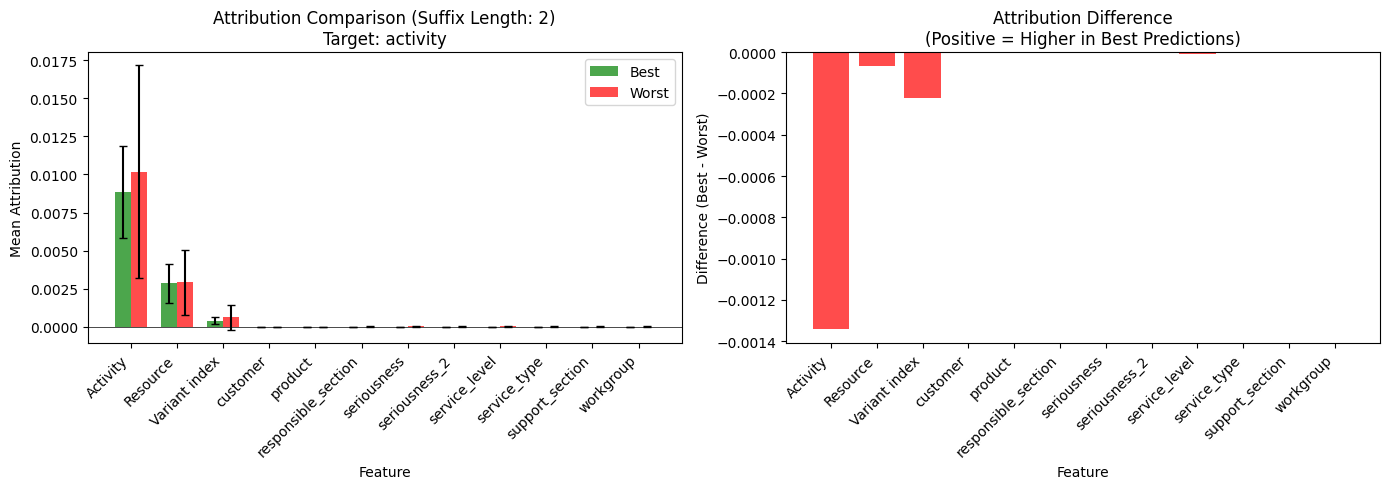

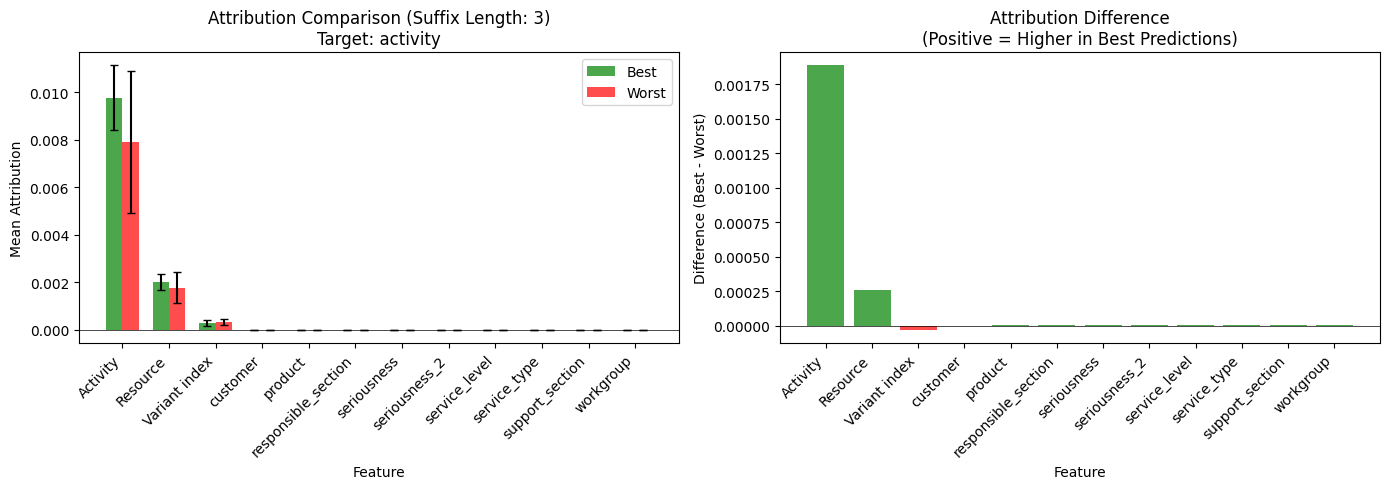

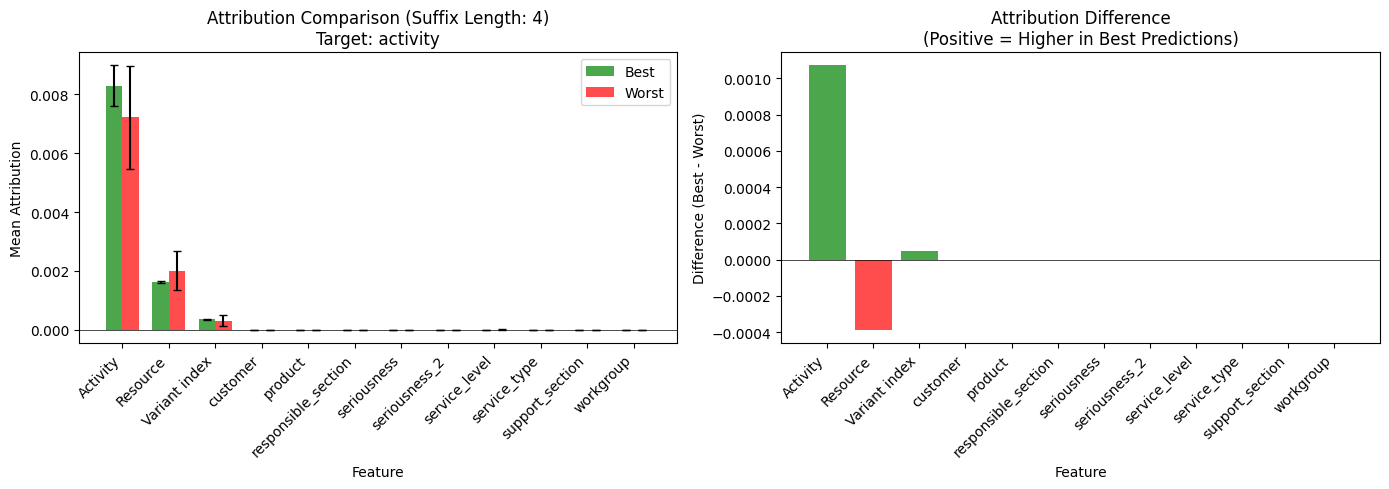

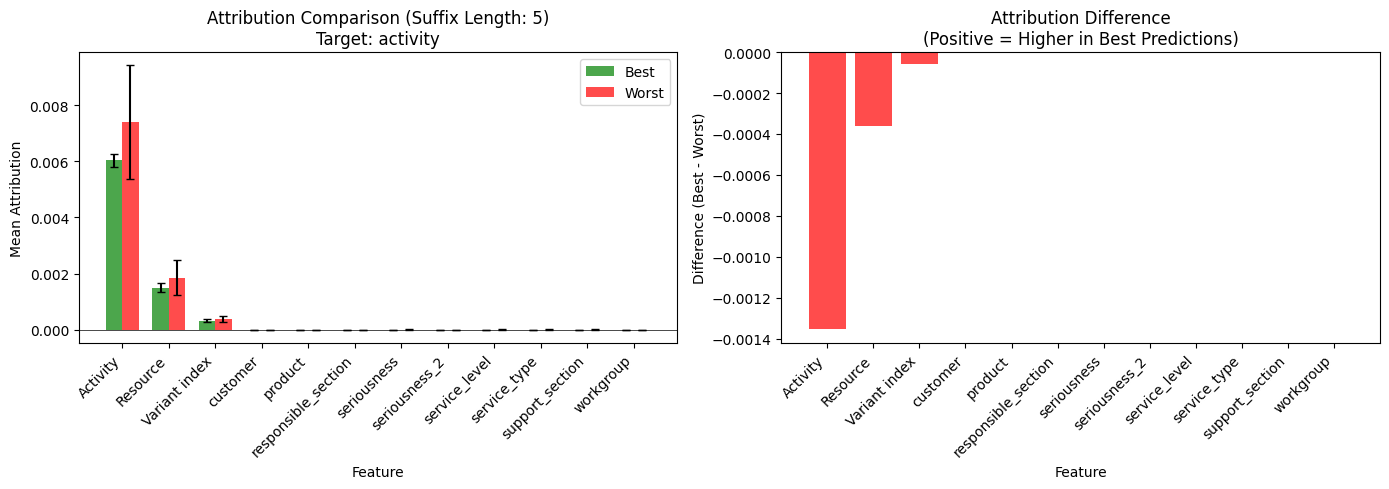

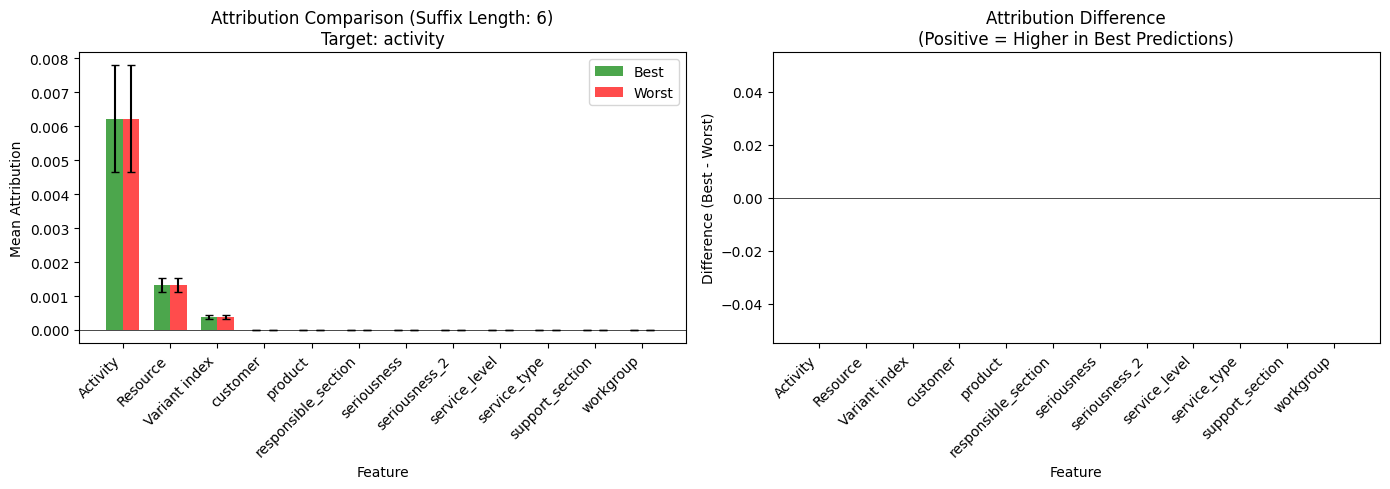

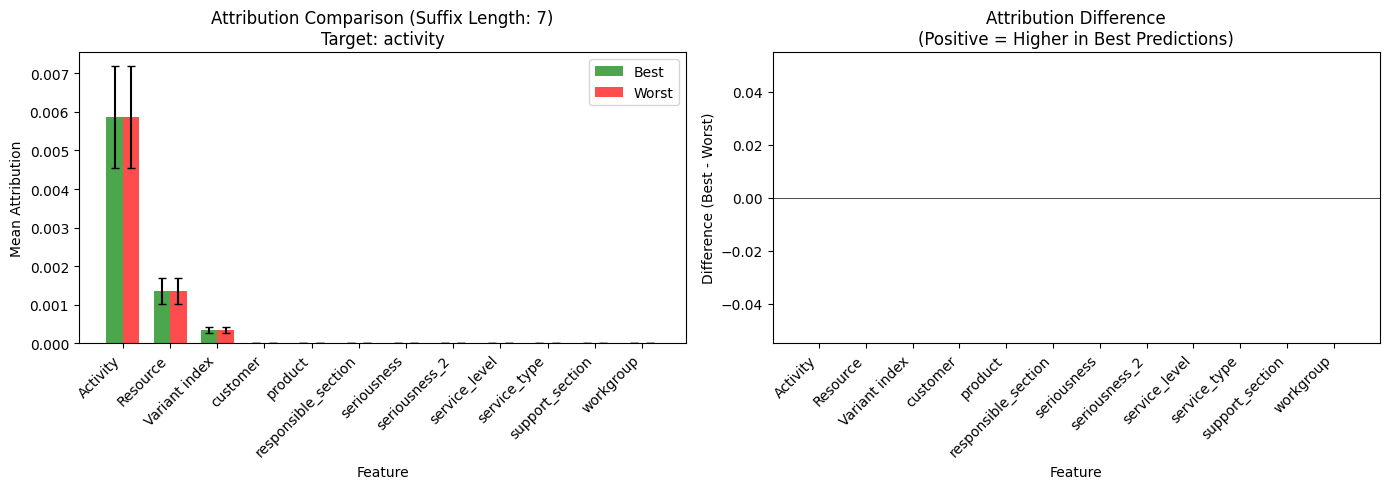

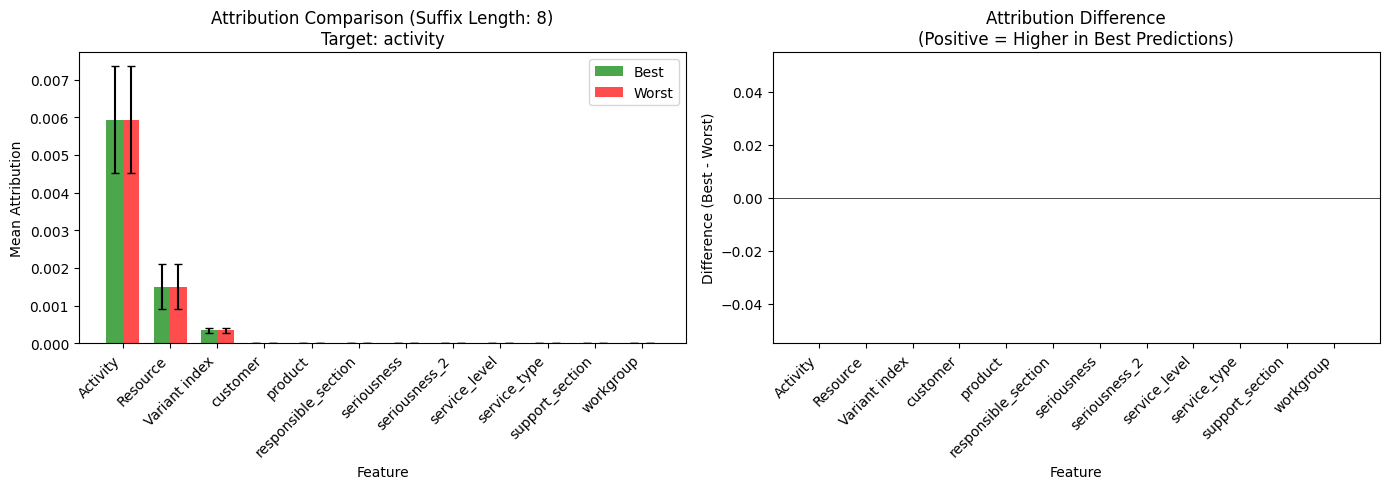

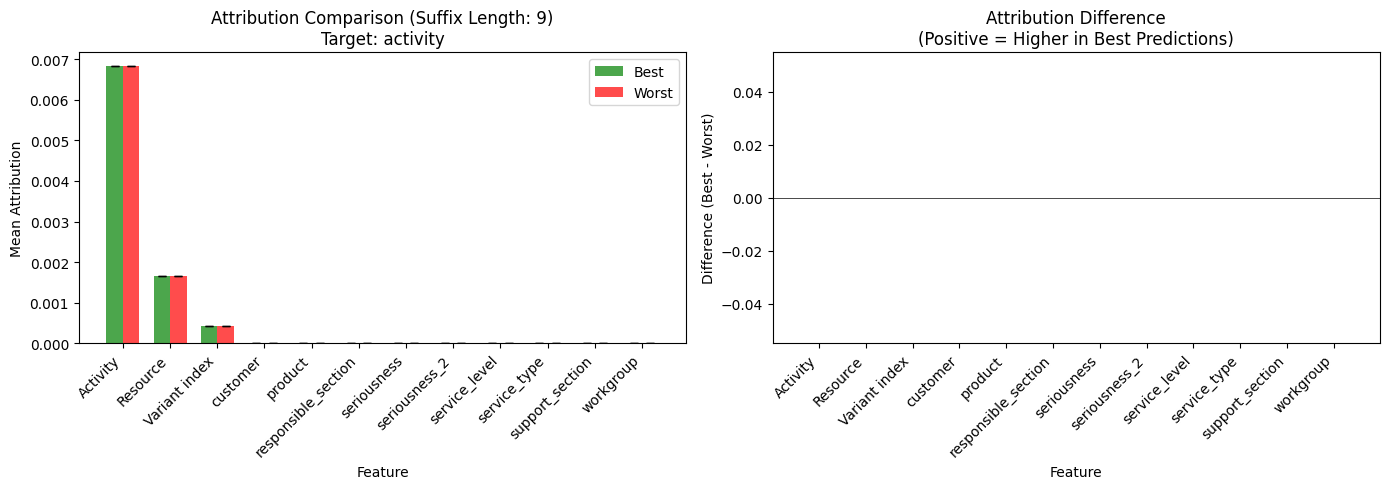

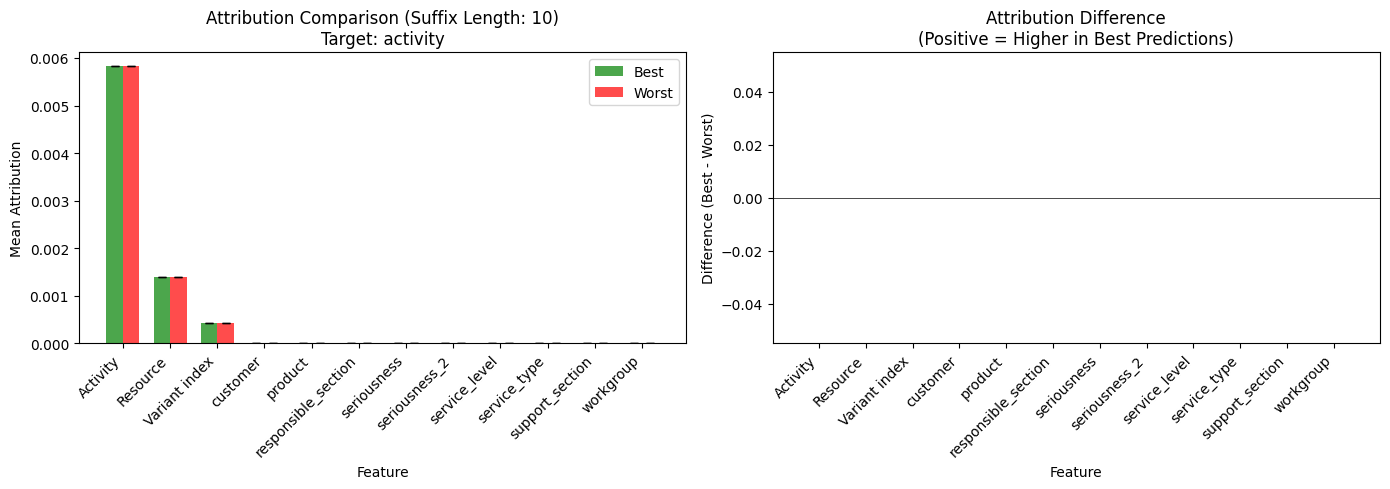

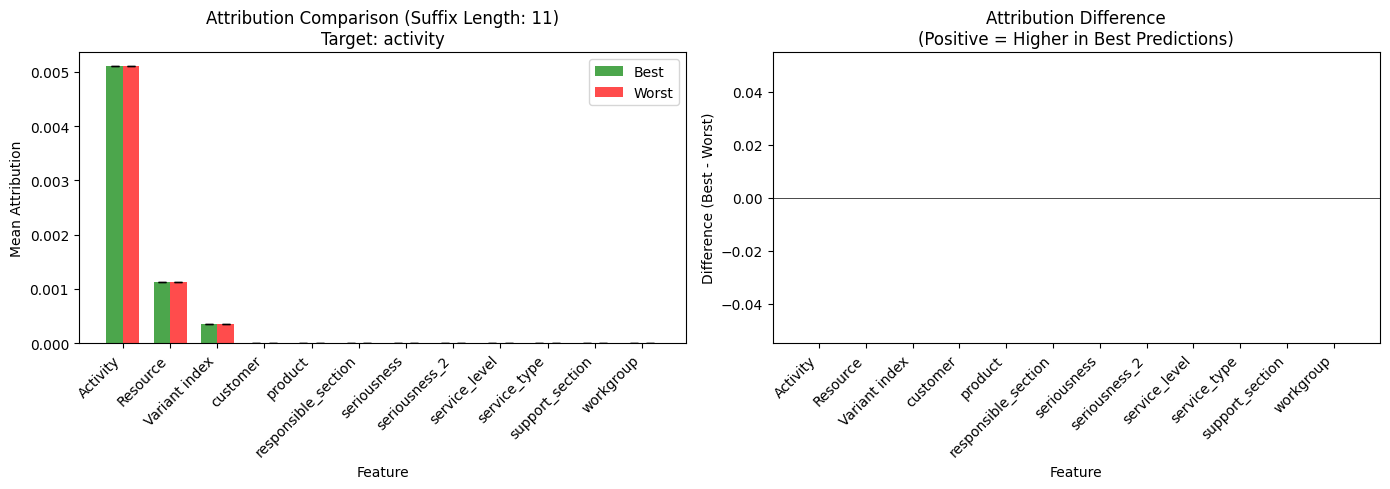

In [71]:
def plot_attribution_comparison(comparison_df, suffix_len, target_type):
    """Create bar plot comparing best vs worst attributions."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    features = comparison_df['Feature'].tolist()
    x = np.arange(len(features))
    width = 0.35
    
    # Plot means
    ax = axes[0]
    bars1 = ax.bar(x - width/2, comparison_df['Best (mean)'], width, 
                   label='Best', color='green', alpha=0.7,
                   yerr=comparison_df['Best (std)'], capsize=3)
    bars2 = ax.bar(x + width/2, comparison_df['Worst (mean)'], width,
                   label='Worst', color='red', alpha=0.7,
                   yerr=comparison_df['Worst (std)'], capsize=3)
    
    ax.set_xlabel('Feature')
    ax.set_ylabel('Mean Attribution')
    ax.set_title(f'Attribution Comparison (Suffix Length: {suffix_len})\nTarget: {target_type}')
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=45, ha='right')
    ax.legend()
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Plot difference
    ax = axes[1]
    colors = ['green' if d > 0 else 'red' for d in comparison_df['Difference']]
    ax.bar(x, comparison_df['Difference'], color=colors, alpha=0.7)
    
    ax.set_xlabel('Feature')
    ax.set_ylabel('Difference (Best - Worst)')
    ax.set_title(f'Attribution Difference\n(Positive = Higher in Best Predictions)')
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=45, ha='right')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    return fig


# Plot for each suffix length
for suffix_len in sorted(comparisons.keys()):
    if len(comparisons[suffix_len]) > 0:
        fig = plot_attribution_comparison(comparisons[suffix_len], suffix_len, TARGET_TYPE)
        plt.show()

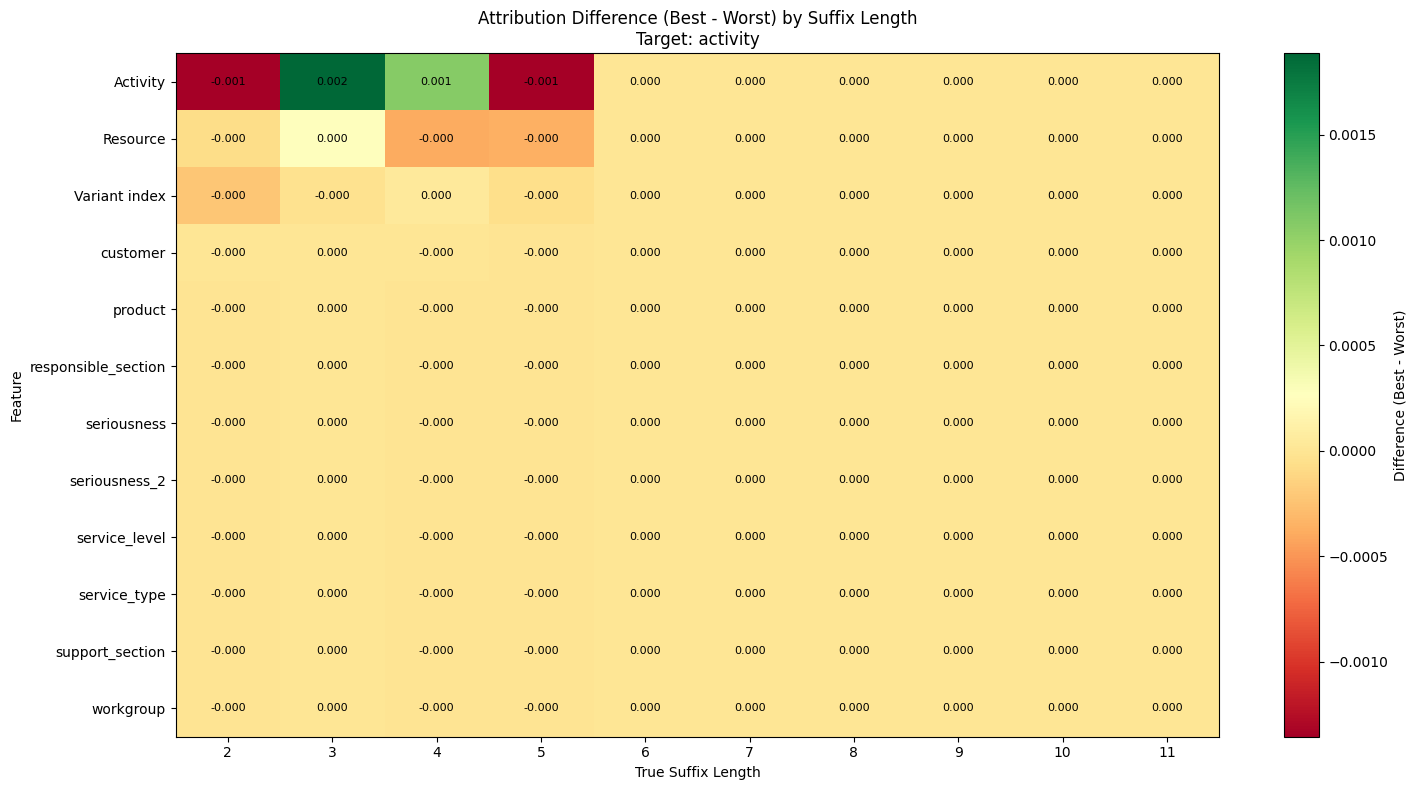

In [72]:
def plot_attribution_heatmap_by_suffix_len(comparisons, target_type):
    """Create heatmap showing attribution differences across suffix lengths."""
    if not comparisons:
        print("No comparisons to plot")
        return
    
    # Get all features
    all_features = set()
    for comp in comparisons.values():
        all_features.update(comp['Feature'].tolist())
    all_features = sorted(all_features)
    
    # Create matrix
    suffix_lens = sorted(comparisons.keys())
    matrix = np.zeros((len(all_features), len(suffix_lens)))
    
    for j, suffix_len in enumerate(suffix_lens):
        comp = comparisons[suffix_len]
        for i, feat in enumerate(all_features):
            row = comp[comp['Feature'] == feat]
            if len(row) > 0:
                matrix[i, j] = row['Difference'].values[0]
    
    # Plot
    fig, ax = plt.subplots(figsize=(max(10, len(suffix_lens) * 1.5), len(all_features) * 0.5 + 2))
    
    im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto')
    
    ax.set_xticks(range(len(suffix_lens)))
    ax.set_xticklabels(suffix_lens)
    ax.set_yticks(range(len(all_features)))
    ax.set_yticklabels(all_features)
    
    ax.set_xlabel('True Suffix Length')
    ax.set_ylabel('Feature')
    ax.set_title(f'Attribution Difference (Best - Worst) by Suffix Length\nTarget: {target_type}')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Difference (Best - Worst)')
    
    # Add value annotations
    for i in range(len(all_features)):
        for j in range(len(suffix_lens)):
            text = ax.text(j, i, f'{matrix[i, j]:.3f}',
                          ha='center', va='center', color='black', fontsize=8)
    
    plt.tight_layout()
    return fig


# Create heatmap
if comparisons:
    fig = plot_attribution_heatmap_by_suffix_len(comparisons, TARGET_TYPE)
    plt.show()

## Save Results

In [73]:
# Save results
output_filename = f"suffix_aggregation_results_{TARGET_TYPE}.pkl"

with open(output_filename, 'wb') as f:
    pickle.dump({
        'results_df': results_df,
        'best_worst': best_worst,
        'comparisons': comparisons,
        'config': {
            'target_type': TARGET_TYPE,
            'top_k': TOP_K,
            'ig_steps': IG_STEPS,
            'max_suffix_len': MAX_SUFFIX_LEN
        }
    }, f)

print(f"Results saved to: {output_filename}")

Results saved to: suffix_aggregation_results_activity.pkl


## Summary Statistics

In [74]:
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nTarget type: {TARGET_TYPE}")
print(f"Total predictions analyzed: {len(results_df)}")
print(f"Unique cases: {results_df['case_name'].nunique()}")

print(f"\nPredicted suffix length distribution:")
print(results_df['suffix_len'].value_counts().sort_index())

print(f"\nTrue suffix length distribution:")
print(results_df['true_suffix_len'].value_counts().sort_index())

print(f"\nOverall prediction quality:")
print(f"  Mean accuracy: {results_df['accuracy'].mean():.4f}")
print(f"  Mean Levenshtein distance: {results_df['levenshtein'].mean():.4f}")
print(f"  Mean probability (per step): {results_df['mean_probability'].mean():.4f}")

# WEIGHTED attribution summary
print(f"\n--- WEIGHTED Attribution Summary ---")
print("Formula: Σ(prob_i × attr_i) / Σ(prob_i)")
all_weighted_attrs = []
for _, row in results_df.iterrows():
    attrs = row.get('weighted_attributions', {})
    if attrs:
        all_weighted_attrs.append(attrs)

if all_weighted_attrs:
    features = set()
    for attrs in all_weighted_attrs:
        features.update(attrs.keys())
    
    print(f"Mean absolute attribution by feature:")
    for feat in sorted(features):
        values = [abs(attrs.get(feat, 0)) for attrs in all_weighted_attrs]
        print(f"  {feat:25s}: {np.mean(values):.6f}")

# UNWEIGHTED attribution summary
print(f"\n--- UNWEIGHTED Attribution Summary ---")
print("Formula: Σ(attr_i) / n")
all_unweighted_attrs = []
for _, row in results_df.iterrows():
    attrs = row.get('unweighted_attributions', {})
    if attrs:
        all_unweighted_attrs.append(attrs)

if all_unweighted_attrs:
    features = set()
    for attrs in all_unweighted_attrs:
        features.update(attrs.keys())
    
    print(f"Mean absolute attribution by feature:")
    for feat in sorted(features):
        values = [abs(attrs.get(feat, 0)) for attrs in all_unweighted_attrs]
        print(f"  {feat:25s}: {np.mean(values):.6f}")


SUMMARY STATISTICS

Target type: activity
Total predictions analyzed: 185
Unique cases: 50

Predicted suffix length distribution:
suffix_len
2    52
3    86
4    31
5    10
6     5
7     1
Name: count, dtype: int64

True suffix length distribution:
true_suffix_len
2     50
3     50
4     48
5     18
6     10
7      4
8      2
9      1
10     1
11     1
Name: count, dtype: int64

Overall prediction quality:
  Mean accuracy: 0.6128
  Mean Levenshtein distance: 0.6324
  Mean probability (per step): 0.8067

--- WEIGHTED Attribution Summary ---
Formula: Σ(prob_i × attr_i) / Σ(prob_i)
Mean absolute attribution by feature:
  Activity                 : 0.009687
  Resource                 : 0.002284
  Variant index            : 0.000430
  customer                 : 0.000001
  product                  : 0.000003
  responsible_section      : 0.000004
  seriousness              : 0.000008
  seriousness_2            : 0.000003
  service_level            : 0.000008
  service_type             : 0.00